<a href="https://colab.research.google.com/github/aditibhat017-prog/cognitivefunction/blob/main/notebooks/03_predictive_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Modeling of Cognitive Performance

## Objective

This notebook evaluates whether wearable-derived physical activity features improve out-of-sample prediction of cognitive performance beyond demographic characteristics alone.

Models using demographic predictors are compared with models incorporating wearable-derived activity features.

## Primary Question

Does adding wearable-derived mean daily physical activity improve prediction of Digit Symbol Substitution Test (DSST) performance beyond age, sex, and education?

## Modeling Strategy

Two primary feature sets are compared:

1. **Demographic model:** Age + Sex + Education
2. **Demographic + Wearable model:** Age + Sex + Education + Mean Daily Activity

Model performance will be evaluated using cross-validation and held-out data rather than in-sample model fit.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
RANDOM_STATE = 42

## 2. Load Processed Analysis Data

Participant-level datasets generated during the primary and replication analyses are combined for predictive modeling. A survey-cycle indicator is retained to identify the source cohort.

In [4]:
df_g = pd.read_csv(
    "/content/nhanes_2011_2012_analysis.csv"
)

df_h = pd.read_csv(
    "/content/nhanes_2013_2014_analysis.csv"
)

print("2011–2012:", df_g.shape)
print("2013–2014:", df_h.shape)

2011–2012: (1289, 10)
2013–2014: (1386, 10)


In [5]:
df = pd.concat(
    [df_g, df_h],
    ignore_index=True
)

print("Combined:", df.shape)

df.head()

Combined: (2675, 10)


,SEQN,RIDAGEYR,RIAGENDR,DMDEDUC2,mean_daily_activity,activity_sd,activity_cv,valid_days,CFDDS,cycle
0,62174.0,80.0,1.0,5.0,7788.867125,3444.177937,0.442192,8.0,33.0,2011-2012
1,62178.0,80.0,1.0,3.0,6551.497556,2129.729791,0.325075,9.0,38.0,2011-2012
2,62191.0,70.0,1.0,3.0,6287.154111,2520.143523,0.400840,9.0,26.0,2011-2012
3,62215.0,65.0,2.0,4.0,13966.214333,6456.378044,0.462285,9.0,47.0,2011-2012
4,62217.0,77.0,2.0,1.0,12118.276000,3903.646207,0.322129,9.0,25.0,2011-2012


In [6]:
print(df.isna().sum())

print("\nCycles:")
print(df["cycle"].value_counts())

print("\nDSST:")
print(df["CFDDS"].describe())

print("\nActivity:")
print(df["mean_daily_activity"].describe())

SEQN                   0
RIDAGEYR               0
RIAGENDR               0
DMDEDUC2               0
mean_daily_activity    0
activity_sd            0
activity_cv            0
valid_days             0
CFDDS                  0
cycle                  0
dtype: int64

Cycles:
cycle
2013-2014    1386
2011-2012    1289
Name: count, dtype: int64

DSST:
count    2675.000000
mean       45.817570
std        17.253022
min         1.000000
25%        33.000000
50%        46.000000
75%        58.000000
max       105.000000
Name: CFDDS, dtype: float64

Activity:
count     2675.000000
mean      9829.141988
std       3237.450818
min          1.344667
25%       7711.182222
50%       9725.712000
75%      11871.300944
max      25660.761625
Name: mean_daily_activity, dtype: float64


In [7]:
print("Duplicate participant IDs:",
      df["SEQN"].duplicated().sum())

Duplicate participant IDs: 0


## 3. Define Prediction Features and Outcome

Two feature sets are compared:

1. **Demographic model:** age, sex, and education
2. **Wearable model:** age, sex, education, and mean daily wearable-measured activity

The target variable is DSST cognitive performance.

The primary objective is to determine whether adding wearable-derived activity improves out-of-sample predictive performance beyond demographic characteristics alone.

In [8]:
target = "CFDDS"

demographic_features = [
    "RIDAGEYR",
    "RIAGENDR",
    "DMDEDUC2"
]

wearable_features = [
    "RIDAGEYR",
    "RIAGENDR",
    "DMDEDUC2",
    "mean_daily_activity"
]

X_demo = df[demographic_features]
X_wearable = df[wearable_features]
y = df[target]

print("Participants:", len(df))
print("Demographic predictors:", X_demo.shape)
print("Wearable predictors:", X_wearable.shape)
print("Outcome:", y.shape)

Participants: 2675
Demographic predictors: (2675, 3)
Wearable predictors: (2675, 4)
Outcome: (2675,)


In [9]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_demo_train = X_demo.loc[train_idx]
X_demo_test = X_demo.loc[test_idx]

X_wearable_train = X_wearable.loc[train_idx]
X_wearable_test = X_wearable.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("Training participants:", len(train_idx))
print("Testing participants:", len(test_idx))

Training participants: 2140
Testing participants: 535


In [10]:
demo_numeric = [
    "RIDAGEYR"
]

demo_categorical = [
    "RIAGENDR",
    "DMDEDUC2"
]

demo_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            demo_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            demo_categorical
        )
    ]
)

In [11]:
demo_model = Pipeline(
    steps=[
        ("preprocessor", demo_preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [12]:
demo_model.fit(
    X_demo_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['RIDAGEYR']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['RIAGENDR', 'DMDEDUC2'])])),
                ('regressor', LinearRegression())])

In [13]:
demo_predictions = demo_model.predict(
    X_demo_test
)

In [14]:
demo_mae = mean_absolute_error(
    y_test,
    demo_predictions
)

demo_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        demo_predictions
    )
)

demo_r2 = r2_score(
    y_test,
    demo_predictions
)

print(f"Demographic Model")
print(f"MAE:  {demo_mae:.3f}")
print(f"RMSE: {demo_rmse:.3f}")
print(f"R²:   {demo_r2:.3f}")

Demographic Model
MAE:  10.640
RMSE: 13.299
R²:   0.348


In [15]:
wearable_numeric = [
    "RIDAGEYR",
    "mean_daily_activity"
]

wearable_categorical = [
    "RIAGENDR",
    "DMDEDUC2"
]

wearable_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            wearable_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            wearable_categorical
        )
    ]
)

In [16]:
wearable_model = Pipeline(
    steps=[
        ("preprocessor", wearable_preprocessor),
        ("regressor", LinearRegression())
    ]
)

wearable_model.fit(
    X_wearable_train,
    y_train
)

wearable_predictions = wearable_model.predict(
    X_wearable_test
)

In [17]:
wearable_mae = mean_absolute_error(
    y_test,
    wearable_predictions
)

wearable_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        wearable_predictions
    )
)

wearable_r2 = r2_score(
    y_test,
    wearable_predictions
)

print("Demographic + Wearable Model")
print(f"MAE:  {wearable_mae:.3f}")
print(f"RMSE: {wearable_rmse:.3f}")
print(f"R²:   {wearable_r2:.3f}")

Demographic + Wearable Model
MAE:  10.678
RMSE: 13.313
R²:   0.346


In [18]:
model_comparison = pd.DataFrame({
    "Model": [
        "Demographics",
        "Demographics + Wearable Activity"
    ],
    "MAE": [
        demo_mae,
        wearable_mae
    ],
    "RMSE": [
        demo_rmse,
        wearable_rmse
    ],
    "R_squared": [
        demo_r2,
        wearable_r2
    ]
})

model_comparison.round(4)

,Model,MAE,RMSE,R_squared
0,Demographics,10.6395,13.2992,0.3478
1,Demographics + Wearable Activity,10.6780,13.3133,0.3464


### Initial Predictive Modeling Findings

In the pooled NHANES 2011–2014 sample, adding mean daily wearable-measured activity to age, sex, and education did not improve predictive performance on the held-out test set.

The demographic model achieved an MAE of 10.64, RMSE of 13.30, and R² of 0.348. The demographic + wearable activity model achieved an MAE of 10.68, RMSE of 13.31, and R² of 0.346.

Performance was therefore essentially equivalent between the two models, with the wearable model showing no improvement over demographic predictors alone.

These results suggest that although mean daily activity is independently associated with cognitive performance in adjusted statistical models, this single wearable-derived feature may provide limited incremental value for out-of-sample prediction of DSST performance.

## 9. Cross-Validated Model Comparison

Five-fold cross-validation was used to evaluate whether differences between the demographic and wearable models were consistent across multiple train/test partitions.

In [19]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [20]:
demo_cv = cross_validate(
    demo_model,
    X_demo,
    y,
    cv=cv,
    scoring=scoring
)

In [21]:
wearable_cv = cross_validate(
    wearable_model,
    X_wearable,
    y,
    cv=cv,
    scoring=scoring
)

In [22]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Demographics",
        "Demographics + Wearable Activity"
    ],

    "Mean_MAE": [
        -demo_cv["test_MAE"].mean(),
        -wearable_cv["test_MAE"].mean()
    ],

    "SD_MAE": [
        demo_cv["test_MAE"].std(),
        wearable_cv["test_MAE"].std()
    ],

    "Mean_RMSE": [
        -demo_cv["test_RMSE"].mean(),
        -wearable_cv["test_RMSE"].mean()
    ],

    "SD_RMSE": [
        demo_cv["test_RMSE"].std(),
        wearable_cv["test_RMSE"].std()
    ],

    "Mean_R2": [
        demo_cv["test_R2"].mean(),
        wearable_cv["test_R2"].mean()
    ],

    "SD_R2": [
        demo_cv["test_R2"].std(),
        wearable_cv["test_R2"].std()
    ]
})

cv_comparison.round(4)

,Model,Mean_MAE,SD_MAE,Mean_RMSE,SD_RMSE,Mean_R2,SD_R2
0,Demographics,10.8845,0.2410,13.5696,0.3182,0.3791,0.0281
1,Demographics + Wearable Activity,10.8243,0.2964,13.4898,0.3496,0.3862,0.0332


### Cross-Validation Findings

Across five-fold cross-validation, adding mean daily wearable-measured activity produced a small improvement in prediction of DSST performance beyond demographic characteristics alone.

The demographic model achieved a mean MAE of 10.88, mean RMSE of 13.57, and mean R² of 0.379. Adding mean daily activity reduced mean MAE to 10.82 and RMSE to 13.49, while increasing mean R² to 0.386.

The improvement was modest, indicating that mean daily activity provides limited but potentially useful incremental predictive information beyond age, sex, and education.

These cross-validated results differ slightly from the single held-out test split, in which wearable activity did not improve performance. This suggests that the incremental predictive contribution of mean daily activity is small and may vary across participant samples.

## 10. Cross-Cohort Validation

To evaluate generalizability across independently collected samples, models were trained using one NHANES survey cycle and evaluated on the other survey cycle.

Two validation directions were evaluated:

1. Train on NHANES 2011–2012 and test on NHANES 2013–2014.
2. Train on NHANES 2013–2014 and test on NHANES 2011–2012.

For each direction, demographic-only and demographic + wearable activity models were compared.

In [23]:
def evaluate_predictions(y_true, predictions):
    return {
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, predictions)
        ),
        "R2": r2_score(y_true, predictions)
    }

In [24]:
train_g = df[df["cycle"] == "2011-2012"].copy()
test_h = df[df["cycle"] == "2013-2014"].copy()

print("Training:", len(train_g))
print("Testing:", len(test_h))

Training: 1289
Testing: 1386


In [25]:
demo_model.fit(
    train_g[demographic_features],
    train_g[target]
)

pred_demo_g_to_h = demo_model.predict(
    test_h[demographic_features]
)

demo_g_to_h = evaluate_predictions(
    test_h[target],
    pred_demo_g_to_h
)

In [26]:
wearable_model.fit(
    train_g[wearable_features],
    train_g[target]
)

pred_wearable_g_to_h = wearable_model.predict(
    test_h[wearable_features]
)

wearable_g_to_h = evaluate_predictions(
    test_h[target],
    pred_wearable_g_to_h
)

In [27]:
train_h = df[df["cycle"] == "2013-2014"].copy()
test_g = df[df["cycle"] == "2011-2012"].copy()

In [28]:
demo_model.fit(
    train_h[demographic_features],
    train_h[target]
)

pred_demo_h_to_g = demo_model.predict(
    test_g[demographic_features]
)

demo_h_to_g = evaluate_predictions(
    test_g[target],
    pred_demo_h_to_g
)

In [29]:
wearable_model.fit(
    train_h[wearable_features],
    train_h[target]
)

pred_wearable_h_to_g = wearable_model.predict(
    test_g[wearable_features]
)

wearable_h_to_g = evaluate_predictions(
    test_g[target],
    pred_wearable_h_to_g
)

In [30]:
cross_cohort_results = pd.DataFrame([
    {
        "Train": "2011-2012",
        "Test": "2013-2014",
        "Model": "Demographics",
        **demo_g_to_h
    },
    {
        "Train": "2011-2012",
        "Test": "2013-2014",
        "Model": "Demographics + Wearable",
        **wearable_g_to_h
    },
    {
        "Train": "2013-2014",
        "Test": "2011-2012",
        "Model": "Demographics",
        **demo_h_to_g
    },
    {
        "Train": "2013-2014",
        "Test": "2011-2012",
        "Model": "Demographics + Wearable",
        **wearable_h_to_g
    }
])

cross_cohort_results.round(4)

,Train,Test,Model,MAE,RMSE,R2
0,2011-2012,2013-2014,Demographics,10.9500,13.5416,0.3688
1,2011-2012,2013-2014,Demographics + Wearable,10.8399,13.4314,0.3790
2,2013-2014,2011-2012,Demographics,10.7861,13.6523,0.3881
3,2013-2014,2011-2012,Demographics + Wearable,10.7953,13.6338,0.3898


### Cross-Cohort Validation Findings

Cross-cohort validation provided further evidence that mean daily wearable activity contributes modest predictive information beyond demographic characteristics, although the magnitude of improvement varied between cohorts.

When models were trained on NHANES 2011–2012 and evaluated on NHANES 2013–2014, adding mean daily activity improved MAE from 10.95 to 10.84, RMSE from 13.54 to 13.43, and R² from 0.369 to 0.379.

When models were trained on NHANES 2013–2014 and evaluated on NHANES 2011–2012, predictive performance was nearly identical between models. R² increased slightly from 0.388 to 0.390 and RMSE decreased slightly, while MAE showed a negligible increase.

Together with the five-fold cross-validation results, these findings suggest that mean daily wearable-measured activity provides a small but inconsistent incremental improvement in prediction of DSST cognitive performance beyond age, sex, and education.

## 11. Exploratory Multi-Feature Wearable Model

Mean daily activity captures overall activity volume but may not capture other behavioral patterns relevant to cognitive function. An exploratory model therefore evaluates whether a small set of additional wearable-derived features improves predictive performance.

In [31]:
expanded_wearable_features = [
    "RIDAGEYR",
    "RIAGENDR",
    "DMDEDUC2",
    "mean_daily_activity",
    "activity_sd",
    "activity_cv"
]

In [32]:
X_expanded = df[expanded_wearable_features]

print("Expanded feature set:", X_expanded.shape)
X_expanded.head()

Expanded feature set: (2675, 6)


,RIDAGEYR,RIAGENDR,DMDEDUC2,mean_daily_activity,activity_sd,activity_cv
0,80.0,1.0,5.0,7788.867125,3444.177937,0.442192
1,80.0,1.0,3.0,6551.497556,2129.729791,0.325075
2,70.0,1.0,3.0,6287.154111,2520.143523,0.400840
3,65.0,2.0,4.0,13966.214333,6456.378044,0.462285
4,77.0,2.0,1.0,12118.276000,3903.646207,0.322129


In [33]:
expanded_numeric = [
    "RIDAGEYR",
    "mean_daily_activity",
    "activity_sd",
    "activity_cv"
]

expanded_categorical = [
    "RIAGENDR",
    "DMDEDUC2"
]

In [34]:
expanded_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            expanded_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            expanded_categorical
        )
    ]
)

In [35]:
expanded_model = Pipeline(
    steps=[
        ("preprocessor", expanded_preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [36]:
expanded_cv = cross_validate(
    expanded_model,
    X_expanded,
    y,
    cv=cv,
    scoring=scoring
)

In [37]:
expanded_comparison = pd.DataFrame({
    "Model": [
        "Demographics",
        "Demographics + Mean Activity",
        "Demographics + Activity + Variability"
    ],

    "Mean_MAE": [
        -demo_cv["test_MAE"].mean(),
        -wearable_cv["test_MAE"].mean(),
        -expanded_cv["test_MAE"].mean()
    ],

    "Mean_RMSE": [
        -demo_cv["test_RMSE"].mean(),
        -wearable_cv["test_RMSE"].mean(),
        -expanded_cv["test_RMSE"].mean()
    ],

    "Mean_R2": [
        demo_cv["test_R2"].mean(),
        wearable_cv["test_R2"].mean(),
        expanded_cv["test_R2"].mean()
    ]
})

expanded_comparison.round(4)

,Model,Mean_MAE,Mean_RMSE,Mean_R2
0,Demographics,10.8845,13.5696,0.3791
1,Demographics + Mean Activity,10.8243,13.4898,0.3862
2,Demographics + Activity + Variability,10.8244,13.4883,0.3863


### Exploratory Wearable Feature Findings

Adding activity variability features (`activity_sd` and `activity_cv`) did not meaningfully improve predictive performance beyond mean daily activity alone.

The mean daily activity model achieved a cross-validated R² of 0.3862, compared with 0.3863 for the expanded wearable model. MAE and RMSE were also nearly identical between the two models.

These findings suggest that, among the wearable features evaluated, overall mean daily activity contains most of the available predictive information related to DSST performance. Simple measures of day-to-day activity variability do not provide meaningful additional predictive value.

Therefore, the more parsimonious model incorporating mean daily activity alone is preferred for the primary analysis.

## 12. Summary of Predictive Modeling Results

Three approaches were used to evaluate whether wearable-derived physical activity improves prediction of DSST cognitive performance beyond demographic characteristics:

1. Single held-out train/test evaluation
2. Five-fold cross-validation
3. Cross-cohort validation between NHANES 2011–2012 and 2013–2014

Across five-fold cross-validation, adding mean daily activity produced a small improvement in predictive performance beyond age, sex, and education. Mean R² increased from 0.3791 to 0.3862, while mean MAE and RMSE decreased slightly.

Cross-cohort validation demonstrated that the magnitude of this improvement varied between cohorts. Adding wearable activity improved prediction when models were trained on 2011–2012 and tested on 2013–2014, but produced minimal improvement when the training and testing cohorts were reversed.

Adding activity variability features did not meaningfully improve prediction beyond mean daily activity alone.

Overall, these results suggest that mean daily wearable-measured physical activity provides modest incremental predictive information about cognitive performance beyond demographic characteristics, while simple measures of day-to-day activity variability provide little additional value.

## 13. Overall Conclusion

Across two independent NHANES cohorts, higher mean daily wearable-measured physical activity was consistently associated with better DSST cognitive performance after adjustment for age, sex, and education.

However, the predictive contribution of wearable activity beyond demographic characteristics was modest. Mean daily activity produced a small average improvement in cross-validated prediction, while additional activity variability features provided essentially no improvement.

These findings highlight an important distinction between statistical association and predictive utility: a digital biomarker may demonstrate a reproducible relationship with cognitive performance without substantially improving individual-level prediction.

Future work could investigate richer wearable-derived biomarkers, including temporal activity patterns, sleep characteristics, circadian rhythms, and gait-related features, as well as longitudinal outcomes related to cognitive decline.

## 14. Final Figures

### Figure 1. Mean Daily Activity and Cognitive Performance

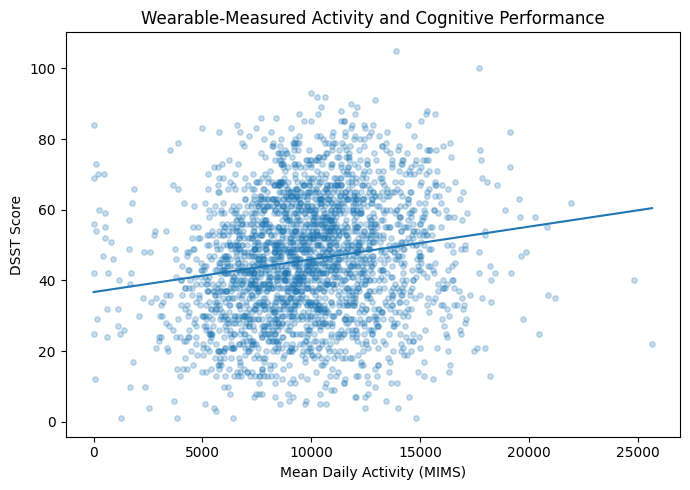

In [47]:
# Figure 1: Mean daily activity vs. DSST

plt.figure(figsize=(7, 5))

plt.scatter(
    df["mean_daily_activity"],
    df["CFDDS"],
    alpha=0.25,
    s=15
)

# Unadjusted linear trend
x = df["mean_daily_activity"]
y = df["CFDDS"]

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

plt.plot(
    x_line,
    slope * x_line + intercept
)

plt.xlabel("Mean Daily Activity (MIMS)")
plt.ylabel("DSST Score")
plt.title("Wearable-Measured Activity and Cognitive Performance")

plt.tight_layout()

plt.savefig(
    "figure1_activity_dsst.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 1.** Relationship between mean daily wearable-measured activity and DSST cognitive performance across the pooled NHANES 2011–2014 sample. Points represent individual participants and the line represents the unadjusted linear trend. Adjusted associations accounting for age, sex, and education were evaluated separately using multivariable regression.

### Figure 2. Replication of the Adjusted Activity Association

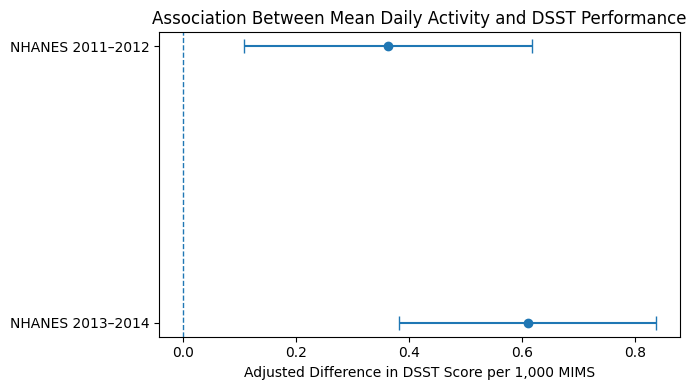

In [48]:
# Figure 2: Adjusted activity effects across cohorts

cohorts = [
    "NHANES 2013–2014",
    "NHANES 2011–2012"
]

effects = [
    0.610,
    0.362
]

lower_ci = [
    0.382,
    0.107
]

upper_ci = [
    0.837,
    0.617
]

errors = [
    [
        effects[i] - lower_ci[i]
        for i in range(len(effects))
    ],
    [
        upper_ci[i] - effects[i]
        for i in range(len(effects))
    ]
]

plt.figure(figsize=(7, 4))

plt.errorbar(
    effects,
    cohorts,
    xerr=errors,
    fmt="o",
    capsize=5
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Adjusted Difference in DSST Score per 1,000 MIMS"
)

plt.title(
    "Association Between Mean Daily Activity and DSST Performance"
)

plt.tight_layout()

plt.savefig(
    "figure2_replication_effects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 2.** Adjusted associations between mean daily wearable-measured activity and DSST performance across independent NHANES cohorts. Points represent regression coefficients per 1,000 MIMS and error bars represent 95% confidence intervals. Models were adjusted for age, sex, and education. Positive associations were observed in both cohorts.

### Figure 3. Cross-Validated Predictive Performance

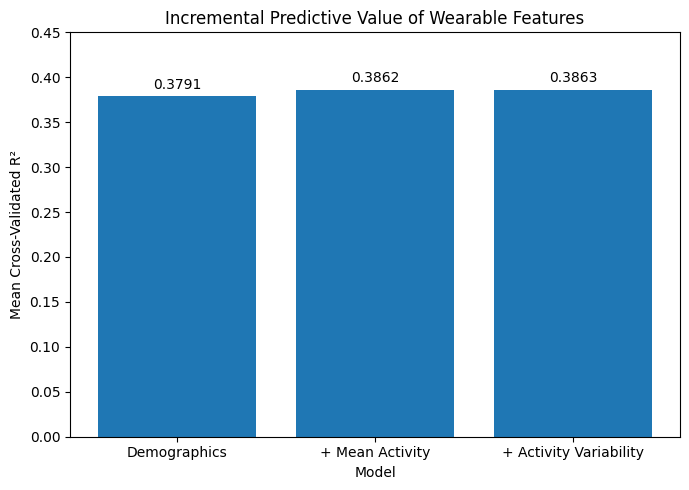

In [49]:
# Figure 3: Cross-validated model performance

models = [
    "Demographics",
    "+ Mean Activity",
    "+ Activity Variability"
]

r2_values = [
    0.3791,
    0.3862,
    0.3863
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    models,
    r2_values
)

for bar, value in zip(bars, r2_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Mean Cross-Validated R²")
plt.xlabel("Model")

plt.title(
    "Incremental Predictive Value of Wearable Features"
)

plt.ylim(0, 0.45)

plt.tight_layout()

plt.savefig(
    "figure3_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 3.** Mean out-of-sample R² from five-fold cross-validation. Adding mean daily activity to demographic predictors produced a small improvement in predictive performance, while the addition of activity variability features provided essentially no further improvement.

### Final Results Summary

In [50]:
final_results = pd.DataFrame({
    "Analysis": [
        "2013–2014 adjusted association",
        "2011–2012 adjusted association",
        "5-fold CV: Demographics",
        "5-fold CV: + Mean Activity",
        "5-fold CV: + Variability"
    ],
    "Result": [
        "β = 0.610 (95% CI: 0.382–0.837)",
        "β = 0.362 (95% CI: 0.107–0.617)",
        "R² = 0.3791",
        "R² = 0.3862",
        "R² = 0.3863"
    ],
    "Interpretation": [
        "Significant positive adjusted association",
        "Significant positive association in replication cohort",
        "Baseline predictive performance",
        "Small predictive improvement",
        "No meaningful additional improvement"
    ]
})

final_results

,Analysis,Result,Interpretation
0,2013–2014 adjusted association,β = 0.610 (95% CI: 0.382–0.837),Significant positive adjusted association
1,2011–2012 adjusted association,β = 0.362 (95% CI: 0.107–0.617),Significant positive association in replicatio...
2,5-fold CV: Demographics,R² = 0.3791,Baseline predictive performance
3,5-fold CV: + Mean Activity,R² = 0.3862,Small predictive improvement
4,5-fold CV: + Variability,R² = 0.3863,No meaningful additional improvement


In [51]:
final_results.to_csv(
    "final_results_summary.csv",
    index=False
)

print("Final results table saved.")

Final results table saved.
